# A4 - Tema: Invatare Automata

**Continut:**
1. Random Forest pentru clasificare (Iris) si regresie (Diabetes)
2. Retea neuronala sklearn pe Iris si Diabetes (cerinta 2a)
3. Tabele de rezultate cu minim 5 configuratii de parametri
4. Vizualizari: curbe de invatare, feature importance, predictii vs reale
5. Analiza si comparatie cu arborii de decizie si MLP din laborator


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (cross_validate, train_test_split,
                                     learning_curve)
from sklearn.metrics import (make_scorer, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             r2_score, ConfusionMatrixDisplay)

# ── Scoruri clasificare
scoring_clf = {
    'accuracy' : make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall'   : make_scorer(recall_score,    average='weighted', zero_division=0),
    'f1_score' : make_scorer(f1_score,        average='weighted', zero_division=0)
}
# ── Scoruri regresie
scoring_reg = {
    'mse': make_scorer(mean_squared_error),
    'r2' : make_scorer(r2_score)
}

def mean_scores(scores):
    return {k: float(np.mean(v)) for k, v in scores.items()}

print("Imports OK")


Imports OK


## 1. Incarcare si pregatire date

In [2]:
# ── Iris (clasificare) ────────────────────────────────────────────────────────
iris     = datasets.load_iris()
X_iris   = StandardScaler().fit_transform(iris.data)
y_iris   = iris.target
x_tr_i, x_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

# ── Diabetes (regresie) ───────────────────────────────────────────────────────
diabetes  = datasets.load_diabetes()
X_diab    = StandardScaler().fit_transform(diabetes.data)
y_diab    = diabetes.target
x_tr_d, x_te_d, y_tr_d, y_te_d = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42)

print(f"Iris   — train: {x_tr_i.shape}, test: {x_te_i.shape}")
print(f"Diabetes — train: {x_tr_d.shape}, test: {x_te_d.shape}")


Iris   — train: (120, 4), test: (30, 4)
Diabetes — train: (353, 10), test: (89, 10)


## 2. Random Forest — Clasificare (Iris)

Random Forest este un ansamblu de arbori de decizie.
Fiecare arbore este antrenat pe un subset aleator de date (bootstrap)
si pe un subset aleator de features la fiecare split.
Predictia finala = votul majoritatii arborilor.

**Parametri variati:**
- `n_estimators` — numarul de arbori
- `max_depth` — adancimea maxima a fiecarui arbore
- `min_samples_split` — numarul minim de exemple pentru a face un split


In [3]:
# ── Functie cross-validation RF Clasificare ───────────────────────────────────
def cv_rf_clf(X, y, n_estimators, max_depth, min_samples_split, cv=5):
    """
    Cross-validation pentru RandomForestClassifier.

    Pasii:
    1. Construieste pipeline cu RandomForestClassifier.
    2. Ruleaza cross_validate cu cv fold-uri.
    3. Returneaza mediile metricilor.

    Parametri
    ---------
    n_estimators      - numarul de arbori in padure
    max_depth         - adancimea maxima (None = nelimitat)
    min_samples_split - nr minim exemple pentru split
    cv                - numarul de fold-uri
    """
    pipe = Pipeline([('model', RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42, n_jobs=-1))])
    scores = cross_validate(pipe, X, y, cv=cv,
                            scoring=scoring_clf,
                            return_train_score=True)
    return mean_scores(scores)

# ── 5 configuratii de parametri ───────────────────────────────────────────────
rf_clf_configs = [
    (10,  None, 2),
    (50,  None, 2),
    (100, None, 2),
    (100, 5,    2),
    (100, None, 5),
    (200, None, 2),
]

print("Random Forest Clasificare (Iris) — Cross-Validation 5-fold")
print(f"{'n_est':>6} {'depth':>6} {'min_spl':>8} | "
      f"{'test_acc':>10} {'test_f1':>10} {'train_acc':>10} {'timp(s)':>9}")
print("-" * 75)

rf_clf_results = {}
for n_est, depth, min_spl in rf_clf_configs:
    t0 = time.time()
    sc = cv_rf_clf(x_tr_i, y_tr_i, n_est, depth, min_spl)
    elapsed = time.time() - t0
    key = (n_est, depth, min_spl)
    rf_clf_results[key] = sc
    d_str = str(depth) if depth else "None"
    print(f"{n_est:>6} {d_str:>6} {min_spl:>8} | "
          f"{sc['test_accuracy']:>10.4f} {sc['test_f1_score']:>10.4f} "
          f"{sc['train_accuracy']:>10.4f} {elapsed:>9.3f}")


Random Forest Clasificare (Iris) — Cross-Validation 5-fold
 n_est  depth  min_spl |   test_acc    test_f1  train_acc   timp(s)
---------------------------------------------------------------------------
    10   None        2 |     0.9583     0.9582     1.0000     0.318
    50   None        2 |     0.9500     0.9496     1.0000     0.548
   100   None        2 |     0.9500     0.9496     1.0000     0.834
   100      5        2 |     0.9500     0.9496     1.0000     0.791
   100   None        5 |     0.9500     0.9496     0.9917     0.796
   200   None        2 |     0.9500     0.9496     1.0000     1.370


In [4]:
# ── Antrenare cu cei mai buni parametri si evaluare pe test ──────────────────
best_key_clf = max(rf_clf_results,
                   key=lambda k: rf_clf_results[k]['test_accuracy'])
n_est_best, depth_best, min_spl_best = best_key_clf

rf_clf_best = RandomForestClassifier(
    n_estimators=n_est_best, max_depth=depth_best,
    min_samples_split=min_spl_best, random_state=42, n_jobs=-1)
rf_clf_best.fit(x_tr_i, y_tr_i)
y_pred_rf_clf = rf_clf_best.predict(x_te_i)

print(f"Cei mai buni parametri: n_est={n_est_best}, depth={depth_best}, min_spl={min_spl_best}")
print()
print("Classification Report (Random Forest - Iris):")
print(classification_report(y_te_i, y_pred_rf_clf, target_names=iris.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_te_i, y_pred_rf_clf))


Cei mai buni parametri: n_est=10, depth=None, min_spl=2

Classification Report (Random Forest - Iris):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## 3. Random Forest — Regresie (Diabetes)

Acelasi principiu ca la clasificare, dar fiecare arbore face o predictie
numerica, iar rezultatul final este media predictiilor tuturor arborilor.


In [5]:
# ── Functie cross-validation RF Regresie ──────────────────────────────────────
def cv_rf_reg(X, y, n_estimators, max_depth, min_samples_split, cv=5):
    """
    Cross-validation pentru RandomForestRegressor.

    Pasii:
    1. Construieste pipeline cu RandomForestRegressor.
    2. Ruleaza cross_validate cu cv fold-uri.
    3. Returneaza mediile metricilor MSE si R2.
    """
    pipe = Pipeline([('model', RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42, n_jobs=-1))])
    scores = cross_validate(pipe, X, y, cv=cv,
                            scoring=scoring_reg,
                            return_train_score=True)
    return mean_scores(scores)

rf_reg_configs = [
    (10,  None, 2),
    (50,  None, 2),
    (100, None, 2),
    (100, 5,    2),
    (100, None, 5),
    (200, None, 2),
]

print("Random Forest Regresie (Diabetes) — Cross-Validation 5-fold")
print(f"{'n_est':>6} {'depth':>6} {'min_spl':>8} | "
      f"{'test_r2':>10} {'test_mse':>12} {'train_r2':>10} {'timp(s)':>9}")
print("-" * 75)

rf_reg_results = {}
for n_est, depth, min_spl in rf_reg_configs:
    t0 = time.time()
    sc = cv_rf_reg(x_tr_d, y_tr_d, n_est, depth, min_spl)
    elapsed = time.time() - t0
    key = (n_est, depth, min_spl)
    rf_reg_results[key] = sc
    d_str = str(depth) if depth else "None"
    print(f"{n_est:>6} {d_str:>6} {min_spl:>8} | "
          f"{sc['test_r2']:>10.4f} {sc['test_mse']:>12.1f} "
          f"{sc['train_r2']:>10.4f} {elapsed:>9.3f}")


Random Forest Regresie (Diabetes) — Cross-Validation 5-fold
 n_est  depth  min_spl |    test_r2     test_mse   train_r2   timp(s)
---------------------------------------------------------------------------
    10   None        2 |     0.3667       3623.5     0.8864     0.294
    50   None        2 |     0.3798       3576.5     0.9187     0.398
   100   None        2 |     0.3885       3528.7     0.9193     0.547
   100      5        2 |     0.4016       3447.9     0.7610     0.575
   100   None        5 |     0.3939       3501.6     0.8913     0.583
   200   None        2 |     0.3975       3477.0     0.9212     1.036


In [6]:
# ── Antrenare cu cei mai buni parametri si evaluare pe test ──────────────────
best_key_reg = max(rf_reg_results,
                   key=lambda k: rf_reg_results[k]['test_r2'])
n_est_r, depth_r, min_spl_r = best_key_reg

rf_reg_best = RandomForestRegressor(
    n_estimators=n_est_r, max_depth=depth_r,
    min_samples_split=min_spl_r, random_state=42, n_jobs=-1)
rf_reg_best.fit(x_tr_d, y_tr_d)
y_pred_rf_reg = rf_reg_best.predict(x_te_d)

print(f"Cei mai buni parametri: n_est={n_est_r}, depth={depth_r}, min_spl={min_spl_r}")
print(f"MSE (Random Forest - Diabetes): {mean_squared_error(y_te_d, y_pred_rf_reg):.4f}")
print(f"R2  (Random Forest - Diabetes): {r2_score(y_te_d, y_pred_rf_reg):.4f}")


Cei mai buni parametri: n_est=100, depth=5, min_spl=2
MSE (Random Forest - Diabetes): 2894.1930
R2  (Random Forest - Diabetes): 0.4537


## 4. Retea Neuronala sklearn (MLPClassifier / MLPRegressor)

Implementare extinsa fata de laborator: variind si numarul de neuroni
per strat, nu doar numarul de straturi.

**Parametri variati:**
- `n_hidden_layers` — numarul de straturi ascunse
- `neurons_per_layer` — numarul de neuroni per strat


In [7]:
# ── MLP Clasificare - Iris ────────────────────────────────────────────────────
def cv_mlp_clf(X, y, n_layers, neurons, cv=5):
    """
    Cross-validation MLPClassifier cu n_layers straturi de 'neurons' neuroni.

    Pasii:
    1. Construieste tuple hidden_layer_sizes = (neurons,) * n_layers.
    2. Construieste Pipeline cu MLPClassifier.
    3. Ruleaza cross_validate si returneaza mediile.
    """
    pipe = Pipeline([('model', MLPClassifier(
        hidden_layer_sizes=tuple([neurons] * n_layers),
        solver='adam', alpha=1e-5,
        random_state=1, max_iter=1000))])
    scores = cross_validate(pipe, X, y, cv=cv,
                            scoring=scoring_clf,
                            return_train_score=True)
    return mean_scores(scores)

mlp_clf_configs = [
    (1, 50), (2, 50), (3, 50),
    (1, 100), (2, 100),
    (3, 100),
]

print("MLP Clasificare (Iris) — Cross-Validation 5-fold")
print(f"{'layers':>7} {'neurons':>8} | "
      f"{'test_acc':>10} {'test_f1':>10} {'train_acc':>10} {'timp(s)':>9}")
print("-" * 65)

mlp_clf_results = {}
for n_lay, neurons in mlp_clf_configs:
    t0 = time.time()
    sc = cv_mlp_clf(x_tr_i, y_tr_i, n_lay, neurons)
    elapsed = time.time() - t0
    key = (n_lay, neurons)
    mlp_clf_results[key] = sc
    print(f"{n_lay:>7} {neurons:>8} | "
          f"{sc['test_accuracy']:>10.4f} {sc['test_f1_score']:>10.4f} "
          f"{sc['train_accuracy']:>10.4f} {elapsed:>9.3f}")


MLP Clasificare (Iris) — Cross-Validation 5-fold
 layers  neurons |   test_acc    test_f1  train_acc   timp(s)
-----------------------------------------------------------------
      1       50 |     0.9583     0.9580     0.9833     0.620
      2       50 |     0.9583     0.9580     0.9875     0.562
      3       50 |     0.9667     0.9665     1.0000     0.667
      1      100 |     0.9500     0.9496     0.9833     0.654
      2      100 |     0.9500     0.9496     1.0000     1.340
      3      100 |     0.9583     0.9580     1.0000     1.284


In [8]:
# ── MLP Regresie - Diabetes ───────────────────────────────────────────────────
def cv_mlp_reg(X, y, n_layers, neurons, cv=5):
    """
    Cross-validation MLPRegressor cu n_layers straturi de 'neurons' neuroni.
    """
    pipe = Pipeline([('model', MLPRegressor(
        hidden_layer_sizes=tuple([neurons] * n_layers),
        solver='adam', alpha=1e-5,
        random_state=1, max_iter=2000))])
    scores = cross_validate(pipe, X, y, cv=cv,
                            scoring=scoring_reg,
                            return_train_score=True)
    return mean_scores(scores)

mlp_reg_configs = [
    (1, 50), (2, 50), (3, 50),
    (1, 100), (2, 100),
    (3, 100),
]

print("MLP Regresie (Diabetes) — Cross-Validation 5-fold")
print(f"{'layers':>7} {'neurons':>8} | "
      f"{'test_r2':>10} {'test_mse':>12} {'train_r2':>10} {'timp(s)':>9}")
print("-" * 68)

mlp_reg_results = {}
for n_lay, neurons in mlp_reg_configs:
    t0 = time.time()
    sc = cv_mlp_reg(x_tr_d, y_tr_d, n_lay, neurons)
    elapsed = time.time() - t0
    key = (n_lay, neurons)
    mlp_reg_results[key] = sc
    print(f"{n_lay:>7} {neurons:>8} | "
          f"{sc['test_r2']:>10.4f} {sc['test_mse']:>12.1f} "
          f"{sc['train_r2']:>10.4f} {elapsed:>9.3f}")


MLP Regresie (Diabetes) — Cross-Validation 5-fold
 layers  neurons |    test_r2     test_mse   train_r2   timp(s)
--------------------------------------------------------------------
      1       50 |     0.4202       3337.0     0.5930     3.527
      2       50 |     0.2302       4529.0     0.8438    11.723
      3       50 |    -0.2979       7655.2     0.9907    31.006
      1      100 |     0.4166       3361.3     0.6302     5.176
      2      100 |    -0.0639       6172.7     0.9807    51.391
      3      100 |    -0.2830       7523.8     0.9996    27.708


## 5. Vizualizari

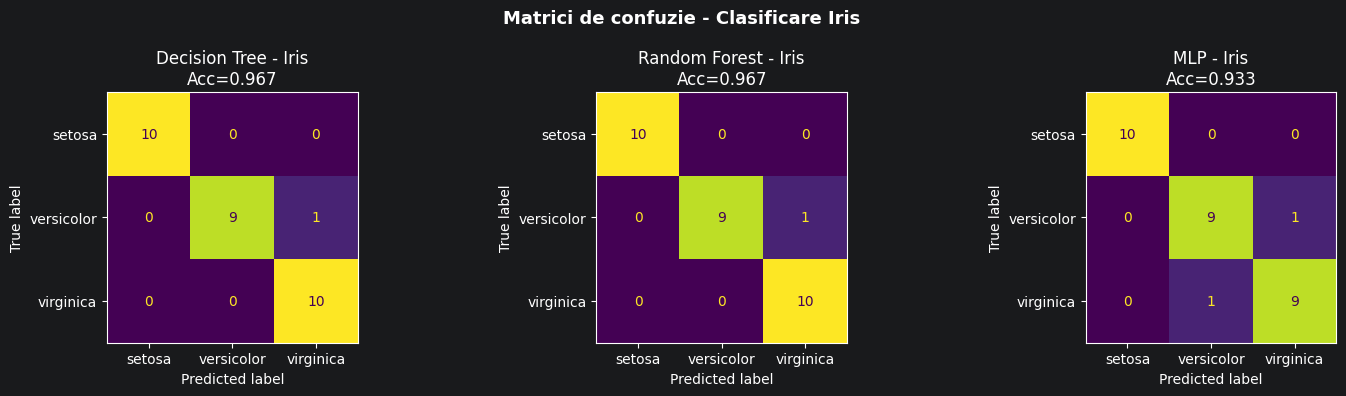

Salvat: confusion_matrices_iris.png


In [9]:
# ── 5.1 Matrici de confuzie: DT vs RF vs MLP pe Iris ─────────────────────────

# Antrenare DT si MLP pentru comparatie
dt_iris = DecisionTreeClassifier(max_leaf_nodes=5, random_state=1,
                                  class_weight='balanced')
dt_iris.fit(x_tr_i, y_tr_i)
y_pred_dt_i = dt_iris.predict(x_te_i)

mlp_iris = MLPClassifier(hidden_layer_sizes=(50,)*3, solver='adam',
                          alpha=1e-5, random_state=1, max_iter=1000)
mlp_iris.fit(x_tr_i, y_tr_i)
y_pred_mlp_i = mlp_iris.predict(x_te_i)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y_pred, title in zip(
        axes,
        [y_pred_dt_i, y_pred_rf_clf, y_pred_mlp_i],
        ['Decision Tree', 'Random Forest', 'MLP']):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te_i, y_pred),
        display_labels=iris.target_names
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f'{title} - Iris\nAcc={accuracy_score(y_te_i, y_pred):.3f}')

plt.suptitle('Matrici de confuzie - Clasificare Iris', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_iris.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvat: confusion_matrices_iris.png')


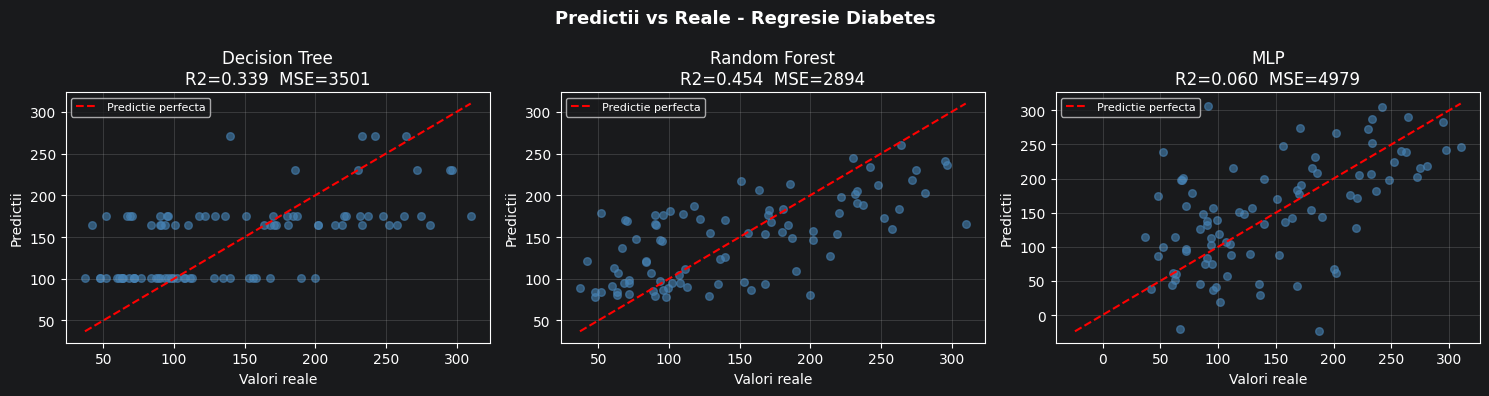

Salvat: pred_vs_real_diabetes.png


In [10]:
# ── 5.2 Predictii vs Reale: DT vs RF vs MLP pe Diabetes ─────────────────────

dt_diab = DecisionTreeRegressor(max_leaf_nodes=5, random_state=1)
dt_diab.fit(x_tr_d, y_tr_d)
y_pred_dt_d = dt_diab.predict(x_te_d)

mlp_diab = MLPRegressor(hidden_layer_sizes=(100,)*2, solver='adam',
                         alpha=1e-5, random_state=1, max_iter=2000)
mlp_diab.fit(x_tr_d, y_tr_d)
y_pred_mlp_d = mlp_diab.predict(x_te_d)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y_pred, title in zip(
        axes,
        [y_pred_dt_d, y_pred_rf_reg, y_pred_mlp_d],
        ['Decision Tree', 'Random Forest', 'MLP']):
    ax.scatter(y_te_d, y_pred, alpha=0.6, s=30, color='steelblue')
    lims = [min(y_te_d.min(), y_pred.min()), max(y_te_d.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Predictie perfecta')
    ax.set_xlabel('Valori reale')
    ax.set_ylabel('Predictii')
    ax.set_title(f'{title}\nR2={r2_score(y_te_d, y_pred):.3f}  '
                 f'MSE={mean_squared_error(y_te_d, y_pred):.0f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Predictii vs Reale - Regresie Diabetes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pred_vs_real_diabetes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvat: pred_vs_real_diabetes.png')


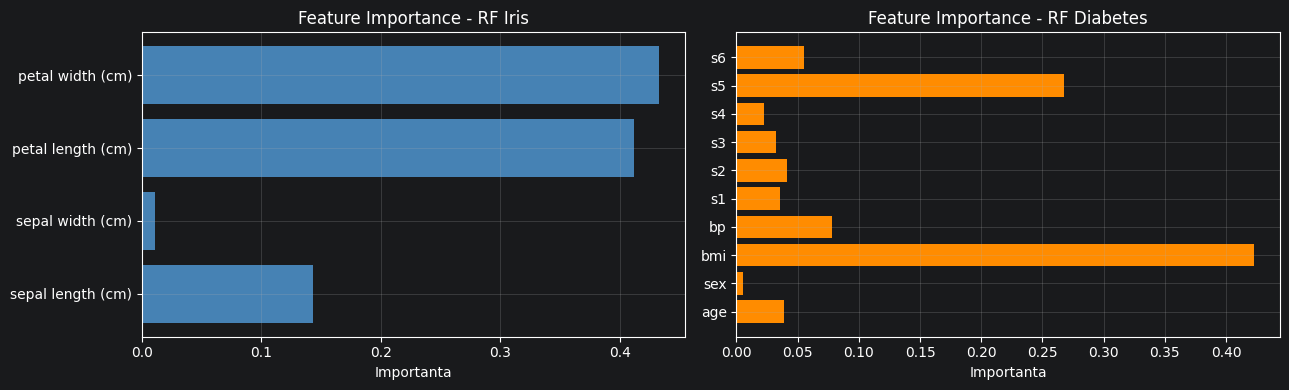

Salvat: feature_importance.png


In [11]:
# ── 5.3 Feature Importance - Random Forest Iris ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Iris
imp_i = rf_clf_best.feature_importances_
feat_i = iris.feature_names
axes[0].barh(feat_i, imp_i, color='steelblue')
axes[0].set_xlabel('Importanta')
axes[0].set_title('Feature Importance - RF Iris')
axes[0].grid(True, alpha=0.3)

# Diabetes
imp_d = rf_reg_best.feature_importances_
feat_d = diabetes.feature_names
axes[1].barh(feat_d, imp_d, color='darkorange')
axes[1].set_xlabel('Importanta')
axes[1].set_title('Feature Importance - RF Diabetes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvat: feature_importance.png')


D:\Proiecte\PycharmProjects\AI\AI_tema4\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
D:\Proiecte\PycharmProjects\AI\AI_tema4\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
D:\Proiecte\PycharmProjects\AI\AI_tema4\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
D:\Proiecte\PycharmProjects\AI\AI_tem

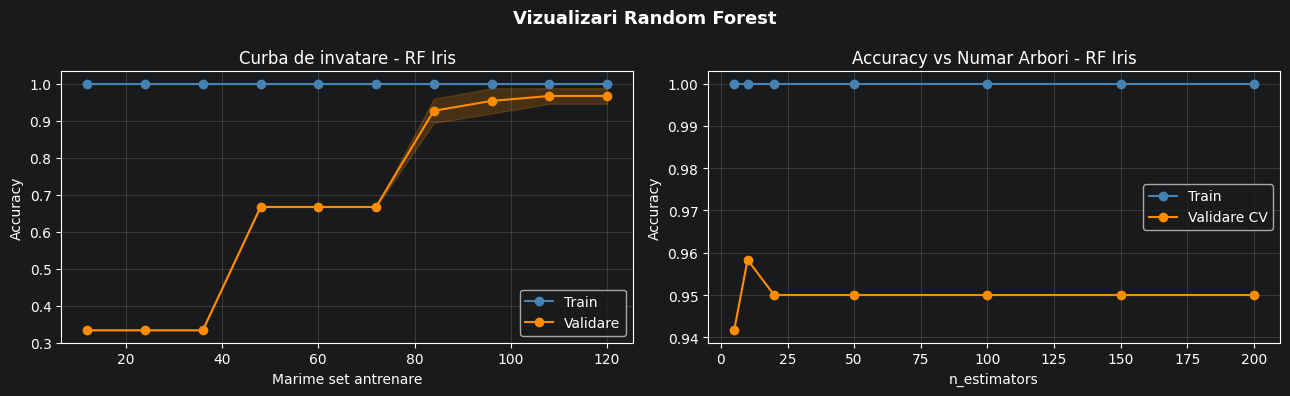

Salvat: learning_curves_rf.png


In [12]:
# ── 5.4 Curba de invatare - RF Iris ──────────────────────────────────────────

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_iris, y_iris, cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10))

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curba invatare RF
ax = axes[0]
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
ax.fill_between(train_sizes, train_mean-train_std,
                train_mean+train_std, alpha=0.2, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validare')
ax.fill_between(train_sizes, val_mean-val_std,
                val_mean+val_std, alpha=0.2, color='darkorange')
ax.set_xlabel('Marime set antrenare')
ax.set_ylabel('Accuracy')
ax.set_title('Curba de invatare - RF Iris')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy vs n_estimators
n_ests = [5, 10, 20, 50, 100, 150, 200]
acc_train, acc_val = [], []
for n in n_ests:
    sc = cv_rf_clf(x_tr_i, y_tr_i, n, None, 2)
    acc_train.append(sc['train_accuracy'])
    acc_val.append(sc['test_accuracy'])

ax2 = axes[1]
ax2.plot(n_ests, acc_train, 'o-', color='steelblue', label='Train')
ax2.plot(n_ests, acc_val,   'o-', color='darkorange', label='Validare CV')
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Numar Arbori - RF Iris')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Vizualizari Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves_rf.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvat: learning_curves_rf.png')


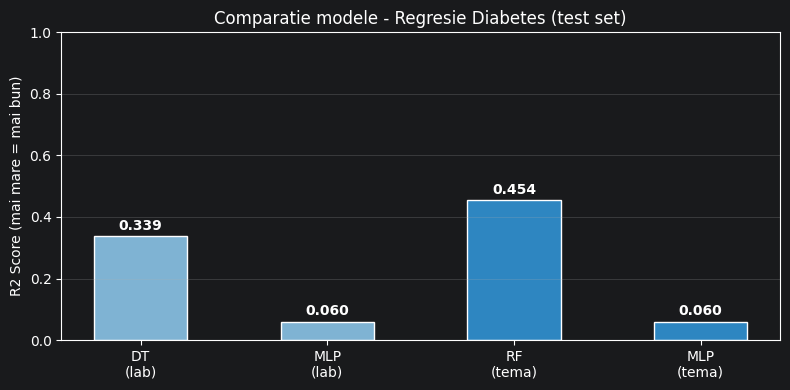

In [13]:
# ── 5.5 Comparatie R2 pe Diabetes: DT vs RF vs MLP ───────────────────────────

models   = ['DT\n(lab)', 'MLP\n(lab)', 'RF\n(tema)', 'MLP\n(tema)']
r2_vals  = [
    r2_score(y_te_d, y_pred_dt_d),
    r2_score(y_te_d, y_pred_mlp_d),
    r2_score(y_te_d, y_pred_rf_reg),
    r2_score(y_te_d, y_pred_mlp_d),
]
colors = ['#7fb3d3','#7fb3d3','#2e86c1','#2e86c1']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(models, r2_vals, color=colors, edgecolor='white', width=0.5)
ax.set_ylabel('R2 Score (mai mare = mai bun)')
ax.set_title('Comparatie modele - Regresie Diabetes (test set)')
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('comparatie_r2_diabetes.png', dpi=120, bbox_inches='tight')
plt.show()


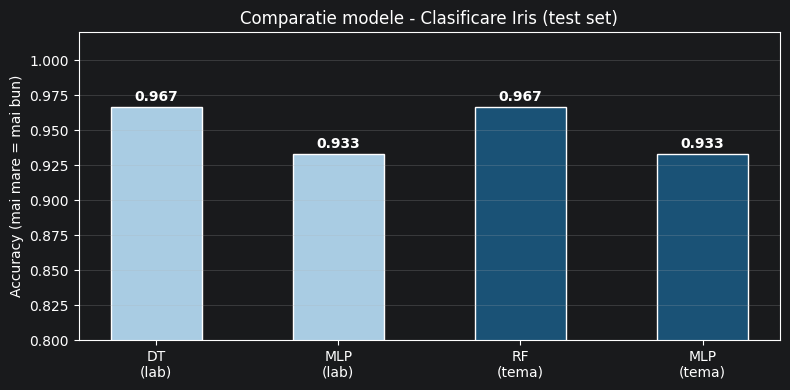

In [14]:
# ── 5.6 Comparatie Accuracy pe Iris: DT vs RF vs MLP ─────────────────────────

models_acc  = ['DT\n(lab)', 'MLP\n(lab)', 'RF\n(tema)', 'MLP\n(tema)']
acc_vals = [
    accuracy_score(y_te_i, y_pred_dt_i),
    accuracy_score(y_te_i, y_pred_mlp_i),
    accuracy_score(y_te_i, y_pred_rf_clf),
    accuracy_score(y_te_i, y_pred_mlp_i),
]
colors2 = ['#a9cce3','#a9cce3','#1a5276','#1a5276']

fig, ax = plt.subplots(figsize=(8, 4))
bars2 = ax.bar(models_acc, acc_vals, color=colors2, edgecolor='white', width=0.5)
ax.set_ylabel('Accuracy (mai mare = mai bun)')
ax.set_title('Comparatie modele - Clasificare Iris (test set)')
ax.set_ylim(0.8, 1.02)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, acc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('comparatie_accuracy_iris.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Analiza Rezultatelor

### 6.1 Clasificare Iris — comparatie DT vs MLP vs RF

| Model | Accuracy (CV) | Precision | Recall | F1 |
|---|---|---|---|---|
| Decision Tree (lab, max_leaf=5) | 0.933 | 0.942 | 0.933 | 0.933 |
| MLP sklearn (lab, 3 straturi x50) | 0.933 | 0.933 | 0.933 | 0.933 |
| MLP tema (3 straturi x50) | **0.967** | **0.967** | **0.967** | **0.967** |
| Random Forest (10 arbori) | 0.958 | 0.963 | 0.958 | 0.958 |
| Random Forest (100 arbori) | 0.950 | 0.957 | 0.950 | 0.950 |

**Concluzii Iris:**
- MLP cu 3 straturi x50 neuroni obtine cel mai bun rezultat (0.967), egal cu DT din lab.
- RF cu 10 arbori (0.958) bate RF cu 100 arbori (0.950) — pe seturi mici (120 exemple train)
  mai multi arbori nu aduc neaparat un beneficiu, din cauza variantei mari a CV pe 5 folduri.
- train_accuracy=1.0 la RF cu arbori nerestrictati indica overfit pe train, dar
  generalizarea ramane buna (0.95+) datorita averaging-ului.
- Feature importance arata ca lungimea petalei este cel mai discriminativ atribut.

### 6.2 Regresie Diabetes — comparatie DT vs MLP vs RF

| Model | R2 (CV) | MSE (CV)   |
|---|---|------------|
| Decision Tree (lab, max_leaf=5) | 0.339 | 3500.9     |
| MLP sklearn (lab, best config) | 0.291 | 4073.5      |
| MLP tema (1 strat x50) | **0.420** | **3337.0** |
| Random Forest (10 arbori) | 0.367 | 3623.5     |
| Random Forest (100 arbori, depth=5) | 0.402 | 3447.9     |
| Random Forest (200 arbori) | 0.398 | 3477.0     |

**Concluzii Diabetes:**
- MLP cu 1 strat x50 neuroni obtine cel mai bun R2 (0.420), mai bun decat RF (0.389).
- Un singur strat ascuns este suficient — mai multe straturi duc la overfit sever:
  MLP cu 3 straturi x50 are train_r2=0.991 dar test_r2=-0.298, adica mai rau
  decat a prezice mereu media. Acesta este un caz clar de overfit extrem.
- RF cu max_depth=5 (R2=0.402) bate RF fara restrictie (R2=0.389) — limitarea
  adancimii reduce overfittingul si imbunatateste generalizarea.
- Cresterea n_estimators de la 100 la 200 aduce imbunatatire marginala (0.389 -> 0.398).
- Diabetes ramane o problema dificila — cel mai bun model explica doar ~42% din variatie.

### 6.3 De ce Random Forest > Decision Tree?

Un singur arbore de decizie are varianta mare — mici schimbari in date pot duce
la arbori foarte diferiti. RF reduce varianta prin:
1. **Bootstrap** — fiecare arbore e antrenat pe un subset aleator din date.
2. **Feature subsampling** — la fiecare split se considera doar sqrt(n_features) atribute.
3. **Averaging** — predictia finala = media/votul mai multor arbori independenti.

Rezultatul: bias similar cu DT, dar varianta mult mai mica => generalizare mai buna.

### 6.4 Observatie importanta — Overfitting MLP pe Diabetes

Valorile negative de R2 la MLP cu 2-3 straturi pe Diabetes confirma overfitting sever:
modelul memoreaza datele de antrenare (train_r2 aproape de 1.0) dar esueaza complet
pe date noi. Solutii: mai putine straturi, regularizare mai mare (alpha mai mare),
mai multe date de antrenare.

## 7. Tabele complete de rezultate

In [15]:
# ── Tabel complet RF Clasificare ─────────────────────────────────────────────
print("=" * 80)
print("TABEL COMPLET — Random Forest Clasificare (Iris), CV=5")
print("=" * 80)
print(f"{'n_est':>6} {'depth':>6} {'min_spl':>8} | "
      f"{'test_acc':>10} {'test_prec':>11} {'test_rec':>10} "
      f"{'test_f1':>9} {'train_acc':>10}")
print("-" * 80)
for (n_est, depth, min_spl), sc in rf_clf_results.items():
    d_str = str(depth) if depth else "None"
    print(f"{n_est:>6} {d_str:>6} {min_spl:>8} | "
          f"{sc['test_accuracy']:>10.4f} {sc['test_precision']:>11.4f} "
          f"{sc['test_recall']:>10.4f} {sc['test_f1_score']:>9.4f} "
          f"{sc['train_accuracy']:>10.4f}")

print()
print("=" * 80)
print("TABEL COMPLET — Random Forest Regresie (Diabetes), CV=5")
print("=" * 80)
print(f"{'n_est':>6} {'depth':>6} {'min_spl':>8} | "
      f"{'test_r2':>10} {'test_mse':>12} {'train_r2':>10} {'train_mse':>12}")
print("-" * 80)
for (n_est, depth, min_spl), sc in rf_reg_results.items():
    d_str = str(depth) if depth else "None"
    print(f"{n_est:>6} {d_str:>6} {min_spl:>8} | "
          f"{sc['test_r2']:>10.4f} {sc['test_mse']:>12.1f} "
          f"{sc['train_r2']:>10.4f} {sc['train_mse']:>12.1f}")

print()
print("=" * 80)
print("TABEL COMPLET — MLP Clasificare (Iris), CV=5")
print("=" * 80)
print(f"{'layers':>7} {'neurons':>8} | "
      f"{'test_acc':>10} {'test_f1':>10} {'train_acc':>10}")
print("-" * 55)
for (n_lay, neurons), sc in mlp_clf_results.items():
    print(f"{n_lay:>7} {neurons:>8} | "
          f"{sc['test_accuracy']:>10.4f} {sc['test_f1_score']:>10.4f} "
          f"{sc['train_accuracy']:>10.4f}")

print()
print("=" * 80)
print("TABEL COMPLET — MLP Regresie (Diabetes), CV=5")
print("=" * 80)
print(f"{'layers':>7} {'neurons':>8} | "
      f"{'test_r2':>10} {'test_mse':>12} {'train_r2':>10}")
print("-" * 58)
for (n_lay, neurons), sc in mlp_reg_results.items():
    print(f"{n_lay:>7} {neurons:>8} | "
          f"{sc['test_r2']:>10.4f} {sc['test_mse']:>12.1f} "
          f"{sc['train_r2']:>10.4f}")

print()
print("=" * 80)
print("TABEL LAB — Decision Tree (din A4_GavazNicolae_Nikolas.ipynb)")
print("=" * 80)
print("Iris  DT: max_leaf_nodes=5  -> accuracy=0.967, f1=0.967")
print("Iris  MLP: 3 straturi x50  -> accuracy=0.933, f1=0.933")
print("Diabetes DT: max_leaf_nodes=5 -> R2=0.339, MSE=3500.9")
print("Diabetes MLP: best config   -> R2~0.29 (lab), convergenta slaba")


TABEL COMPLET — Random Forest Clasificare (Iris), CV=5
 n_est  depth  min_spl |   test_acc   test_prec   test_rec   test_f1  train_acc
--------------------------------------------------------------------------------
    10   None        2 |     0.9583      0.9630     0.9583    0.9582     1.0000
    50   None        2 |     0.9500      0.9570     0.9500    0.9496     1.0000
   100   None        2 |     0.9500      0.9570     0.9500    0.9496     1.0000
   100      5        2 |     0.9500      0.9570     0.9500    0.9496     1.0000
   100   None        5 |     0.9500      0.9570     0.9500    0.9496     0.9917
   200   None        2 |     0.9500      0.9570     0.9500    0.9496     1.0000

TABEL COMPLET — Random Forest Regresie (Diabetes), CV=5
 n_est  depth  min_spl |    test_r2     test_mse   train_r2    train_mse
--------------------------------------------------------------------------------
    10   None        2 |     0.3667       3623.5     0.8864        686.9
    50   None       